# Установка зависимостей

In [1]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

# Импорт

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from keras.preprocessing import sequence
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Загрузка данных

In [3]:
def load_data(num_words=10000):
    (train_data, train_targets), (test_data, test_targets) = imdb.load_data(num_words=num_words)

    data = np.concatenate((train_data, test_data), axis=0)
    targets = np.concatenate((train_targets, test_targets), axis=0)

    return data, targets

In [4]:
num_words = 10000
max_review_length = 500
embedding_dim = 32

data, targets = load_data(num_words=num_words)
word_index = imdb.get_word_index()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Предобработка данных

In [5]:
X_train, X_test, y_train, y_test = train_test_split(data, targets, test_size=0.2, random_state=42)
print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

X_train = sequence.pad_sequences(X_train, maxlen=max_review_length)
X_test = sequence.pad_sequences(X_test, maxlen=max_review_length)
print(f"Форма обучающих данных после паддинга: {X_train.shape}")
print(f"Форма тестовых данных после паддинга: {X_test.shape}")

Размер обучающей выборки: 40000
Размер тестовой выборки: 10000
Форма обучающих данных после паддинга: (40000, 500)
Форма тестовых данных после паддинга: (10000, 500)


# Визуализация

In [6]:
def plot_history(history, title="Графики обучения"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Точность на обучении')
    axes[0].plot(history.history['val_accuracy'], label='Точность на валидации')
    axes[0].set_title(f'{title} - Точность')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Потери на обучении')
    axes[1].plot(history.history['val_loss'], label='Потери на валидации')
    axes[1].set_title(f'{title} - Потери')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

# Простая модель

In [7]:
def build_simple_lstm(vocab_size, max_len, embed_dim):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=max_len))
    model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [8]:
model_lstm = build_simple_lstm(num_words, max_review_length, embedding_dim)
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 787s 1s/step - accuracy: 0.7779 - loss: 0.4705 - val_accuracy: 0.8663 - val_loss: 0.3303
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - accuracy: 0.8342 - loss: 0.3800 - val_accuracy: 0.8416 - val_loss: 0.3904
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 648s 990ms/step - accuracy: 0.8619 - loss: 0.3381 - val_accuracy: 0.8650 - val_loss: 0.3352
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 613s 981ms/step - accuracy: 0.8842 - loss: 0.2919 - val_accuracy: 0.8784 - val_loss: 0.2983
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 627s 988ms/step - accuracy: 0.8960 - loss: 0.2660 - val_accuracy: 0.8736 - val_loss: 0.3071


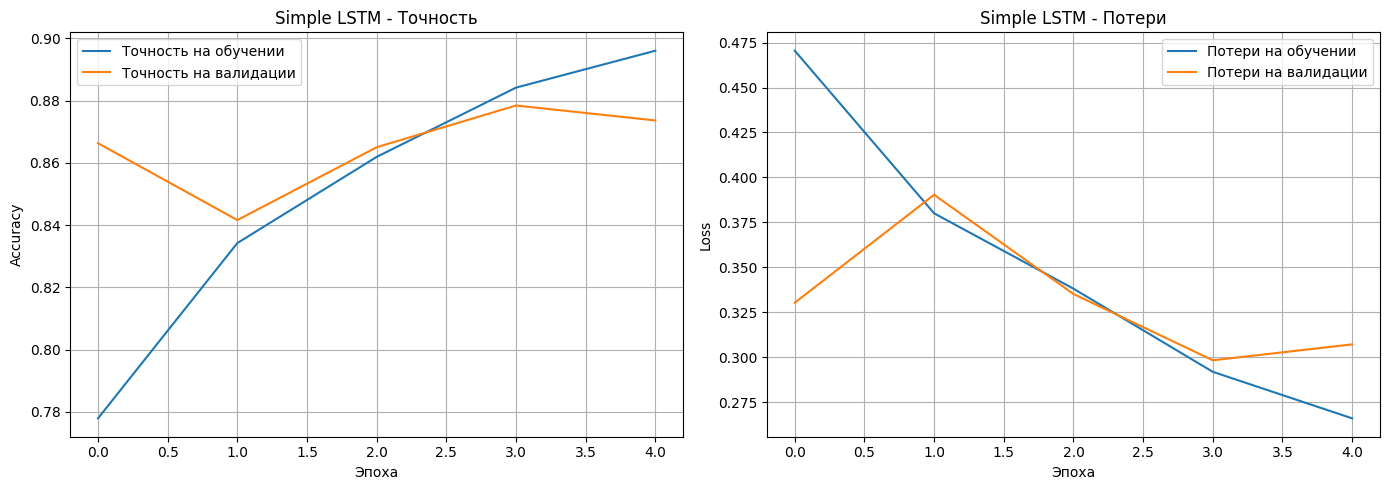

In [9]:
plot_history(history_lstm, "Simple LSTM")

# Модель с дополнительным слоем Dropout

In [10]:
def build_lstm_dropout(vocab_size, max_len, embed_dim):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=max_len))
    model.add(Dropout(0.5))
    model.add(LSTM(128, dropout=0.3, recurrent_dropout=0.3))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [11]:
model_lstm_drop = build_lstm_dropout(num_words, max_review_length, embedding_dim)
model_lstm_drop.summary()

history_lstm_drop = model_lstm_drop.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 854s 1s/step - accuracy: 0.7454 - loss: 0.5107 - val_accuracy: 0.8080 - val_loss: 0.4282
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 852s 1s/step - accuracy: 0.8326 - loss: 0.3966 - val_accuracy: 0.8674 - val_loss: 0.3216
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 889s 1s/step - accuracy: 0.8543 - loss: 0.3550 - val_accuracy: 0.7337 - val_loss: 0.5161
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 902s 1s/step - accuracy: 0.8242 - loss: 0.4053 - val_accuracy: 0.8428 - val_loss: 0.4334
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 852s 1s/step - accuracy: 0.8249 - loss: 0.4055 - val_accuracy: 0.8617 - val_loss: 0.3332


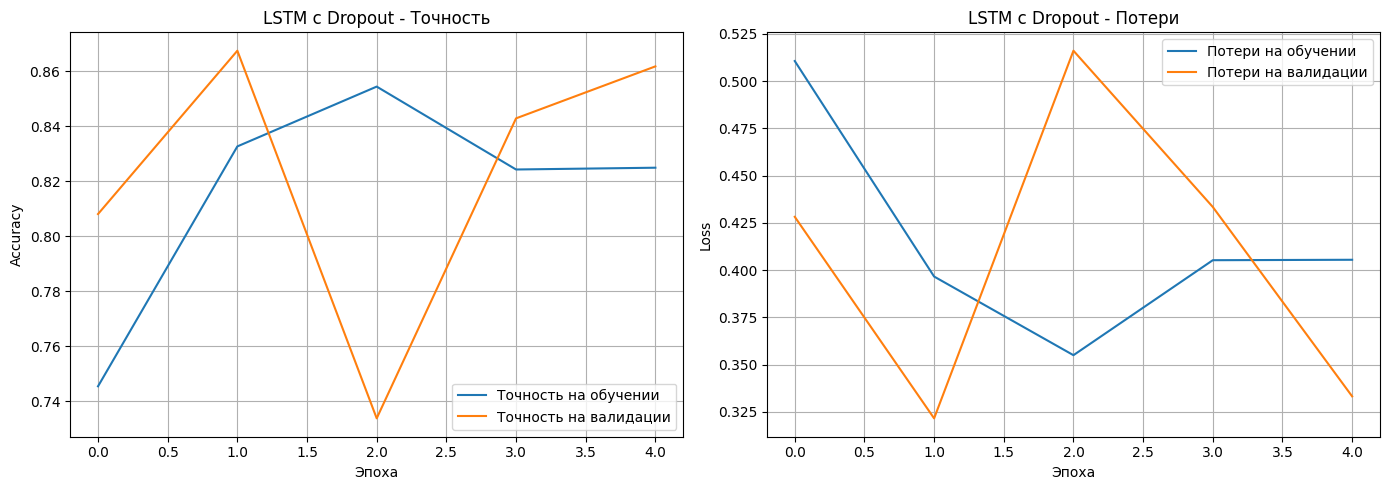

In [12]:
plot_history(history_lstm_drop, "LSTM с Dropout")

# Модель из CNN + LSTM

In [13]:
def build_cnn_lstm(vocab_size, max_len, embed_dim):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=max_len))
    model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [14]:
model_cnn_lstm = build_cnn_lstm(num_words, max_review_length, embedding_dim)
model_cnn_lstm.summary()

history_cnn_lstm = model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 339s 535ms/step - accuracy: 0.7941 - loss: 0.4282 - val_accuracy: 0.8797 - val_loss: 0.2895
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 379s 531ms/step - accuracy: 0.8883 - loss: 0.2800 - val_accuracy: 0.8277 - val_loss: 0.4023
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 374s 519ms/step - accuracy: 0.9100 - loss: 0.2291 - val_accuracy: 0.8766 - val_loss: 0.3004
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 386s 525ms/step - accuracy: 0.9288 - loss: 0.1898 - val_accuracy: 0.9017 - val_loss: 0.2601
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 326s 522ms/step - accuracy: 0.9421 - loss: 0.1563 - val_accuracy: 0.8875 - val_loss: 0.2997


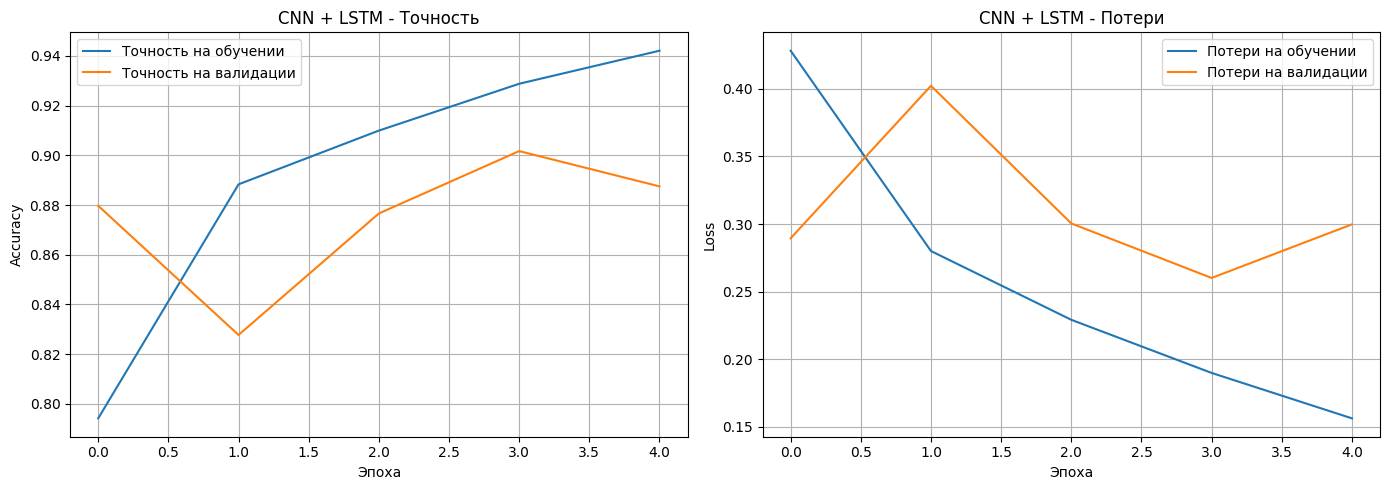

In [15]:
plot_history(history_cnn_lstm, "CNN + LSTM")

# Двухслойная модель LSTM

In [16]:
def build_stacked_lstm(vocab_size, max_len, embed_dim):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=max_len))
    model.add(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [17]:
model_stacked = build_stacked_lstm(num_words, max_review_length, embedding_dim)
model_stacked.summary()

history_stacked = model_stacked.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 826s 1s/step - accuracy: 0.7936 - loss: 0.4406 - val_accuracy: 0.8537 - val_loss: 0.3486
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 813s 1s/step - accuracy: 0.8383 - loss: 0.3711 - val_accuracy: 0.8722 - val_loss: 0.3117
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 882s 1s/step - accuracy: 0.8695 - loss: 0.3305 - val_accuracy: 0.8500 - val_loss: 0.3577
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 859s 1s/step - accuracy: 0.8882 - loss: 0.2827 - val_accuracy: 0.8675 - val_loss: 0.3163
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 832s 1s/step - accuracy: 0.9015 - loss: 0.2524 - val_accuracy: 0.8904 - val_loss: 0.2726


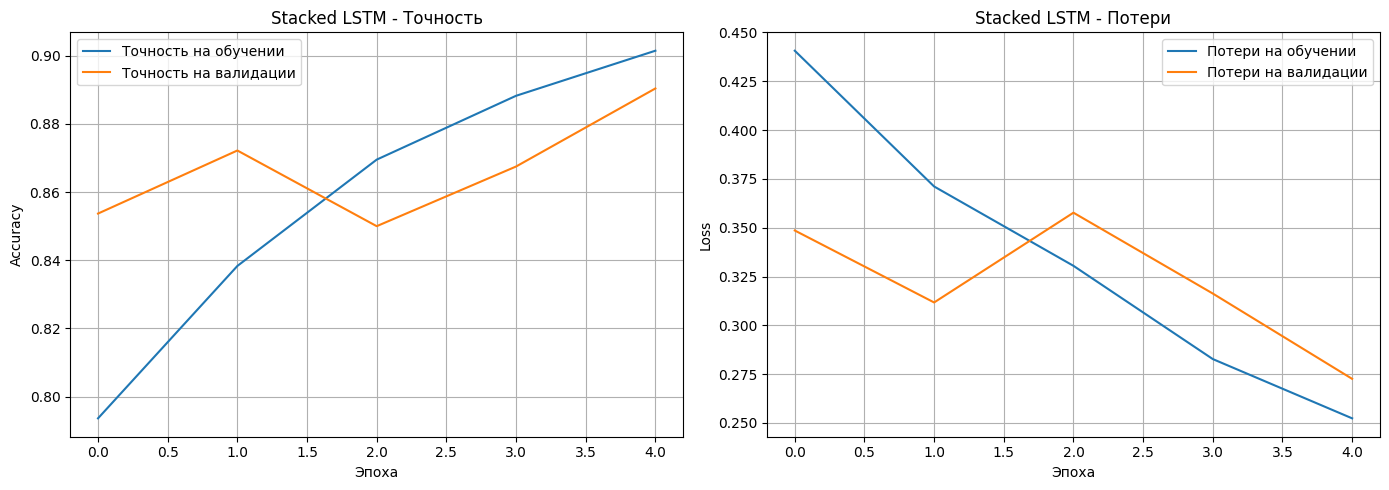

In [18]:
plot_history(history_stacked, "Stacked LSTM")

# Ансамблирование моделей

In [22]:
# Используем обученные модели
models = [model_lstm, model_lstm_drop, model_cnn_lstm, model_stacked]

# Для сравнения, точность каждой отдельной модели:
for i, model in enumerate(models):
    _, acc = model.evaluate(X_test, y_test, verbose=1)
    print(f"Модель {i+1} точность: {acc:.4f}")

# Вычисляем предсказания для тестовой выборки каждой моделью
y_pred_proba = []
for model in models:
    y_pred_proba.append(model.predict(X_test, verbose=1))

# Усредняем вероятности
ensemble_proba = np.mean(y_pred_proba, axis=0)
ensemble_pred = (ensemble_proba > 0.5).astype(int)

# Вычисляем точность ансамбля
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
print(f"Точность ансамбля (усреднение вероятностей): {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.8736 - loss: 0.3071
Модель 1 точность: 0.8736
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 183ms/step - accuracy: 0.8617 - loss: 0.3332
Модель 2 точность: 0.8617
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.8875 - loss: 0.2997
Модель 3 точность: 0.8875
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 210ms/step - accuracy: 0.8904 - loss: 0.2726
Модель 4 точность: 0.8904
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 182ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 212ms/step
Точность ансамбля (усреднение вероятностей): 0.8943 (89.43%)


# Пользовательский текст через ансамблирование

In [23]:
def encode_text(text, word_index, num_words=10000):
    words = text.lower().split()
    encoded = []
    for word in words:
        idx = word_index.get(word)
        if idx is not None and idx < num_words:
            encoded.append(idx + 3)
        else:
            encoded.append(2)
    return encoded

In [26]:
def predict_ensemble(text, models, word_index, max_len=500, num_words=10000):
    encoded = encode_text(text, word_index, num_words)
    padded = sequence.pad_sequences([encoded], maxlen=max_len)
    preds = []
    for model in models:
        prob = model.predict(padded, verbose=0)[0][0]
        preds.append(prob)
    ensemble_prob = np.mean(preds)
    return ensemble_prob, "ПОЛОЖИТЕЛЬНЫЙ" if ensemble_prob > 0.5 else "ОТРИЦАТЕЛЬНЫЙ"

In [37]:
test_texts = [
    "This movie is great amazing wonderful fantastic.",
    "It is terrible movie.",
    "The movie is terrible.",
    "The movie was okay.",
    "The acting was bad but the story was good.",

    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "I hated every minute of it. Boring plot and terrible acting. Complete waste of time.",
    "It was okay, nothing special but not bad either.",
    "The actor casting was bad but the plot was well thought out, overall it's worth watching."
]
for text in test_texts:
    prob, sentiment = predict_ensemble(text, models, word_index, max_len=max_review_length)
    print(f"Текст: {text}")
    print(f"Вероятность положительного отзыва: {prob:.4f}")
    print(f"Результат: {sentiment}")

Текст: This movie is great amazing wonderful fantastic.
Вероятность положительного отзыва: 0.9761
Результат: ПОЛОЖИТЕЛЬНЫЙ
Текст: It is terrible movie.
Вероятность положительного отзыва: 0.3011
Результат: ОТРИЦАТЕЛЬНЫЙ
Текст: The movie is terrible.
Вероятность положительного отзыва: 0.6757
Результат: ПОЛОЖИТЕЛЬНЫЙ
Текст: The movie was okay.
Вероятность положительного отзыва: 0.6372
Результат: ПОЛОЖИТЕЛЬНЫЙ
Текст: The acting was bad but the story was good.
Вероятность положительного отзыва: 0.3615
Результат: ОТРИЦАТЕЛЬНЫЙ
Текст: This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.
Вероятность положительного отзыва: 0.9257
Результат: ПОЛОЖИТЕЛЬНЫЙ
Текст: I hated every minute of it. Boring plot and terrible acting. Complete waste of time.
Вероятность положительного отзыва: 0.0193
Результат: ОТРИЦАТЕЛЬНЫЙ
Текст: It was okay, nothing special but not bad either.
Вероятность положительного отзыва: 0.1901
Результат: ОТРИЦАТЕЛЬНЫЙ
Текст: The a